# ILC method

After the first two steps:
1. Analythical work on g($\nu$),
2. Simultaions of tSZ + CMB + noise signals,

I will start implementing the ILC method.

The code must
1. Compute the correlation matrix: $C_{ij} = \frac{1}{N_P} \Sigma_{p'} \left( d_i(p') \cdot d_j(p') \right)$, (i.e. i,j = 1, ..., 20)
2. Invert $\underline{\underline{C}} \rightarrow \underline{\underline{C^{-1}}}$
3. Compute the weights: $\omega_i = \frac{\underline{\underline{C^{-1}}} \cdot \underline{g}}{\underline{g^\intercal} \cdot \underline{\underline{C^{-1}}} \cdot \underline{g}}$
4. Apply the weights ($\omega_i$) to the data ($d_i$)
5. Get the output: $\hat{y} = \Sigma_i \left( \omega_i \cdot d_i (p) \right) $

In [1]:
### IMPORT PACKAGES ###
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

Emprar vector a = [1,..,1] per provar de fer ILC NOMÉS sobre CMB

In [2]:
### ILC template ###

# This assumes you have a set of frequency maps stored as a list or a 2D array:

def run_basic_ilc(maps, nside_out=128):
    """
    Performs a standard Pixel-Space ILC.
    
    Parameters:
    maps: list or array of healpix maps [n_freq, n_pix]
    nside_out: Resolution for the output map
    """
    n_freq = len(maps)
    n_pix = hp.nside2npix(nside_out)
    
    print(f"Processing ILC with {n_freq} channels...")



    # --- BLOCK 1: Covariance Matrix Estimation ---
    # We need the covariance between different frequency channels.
    # C_ij = < Map_i * Map_j > - <Map_i><Map_j>
    # If maps are zero-mean (common in CMB), it's just the outer product.
    
    # stacking maps: shape (n_freq, n_pix)
    map_stack = np.array(maps)
    
    # Calculate empirical covariance matrix (n_freq x n_freq)
    # We use rowvar=True because each row is a variable (frequency)
    cov_matrix = np.cov(map_stack, rowvar=True)
    
    print("Covariance Matrix calculated:\n", cov_matrix)



    # --- BLOCK 2: Matrix Inversion ---
    # We invert the covariance matrix. 
    # Tip: Use pseudo-inverse (pinv) if the matrix is near-singular.
    try:
        inv_cov = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        print("Warning: Singular matrix, using pseudo-inverse.")
        inv_cov = np.linalg.pinv(cov_matrix)



    # --- BLOCK 3: Weight Calculation ---
    # Constraint vector 'e' is a vector of ones (preserving the CMB blackbody)
    e = np.ones(n_freq)
    
    # Numerator: C^-1 * 1
    numerator = np.dot(inv_cov, e)
    
    # Denominator: 1^T * C^-1 * 1
    denominator = np.dot(e.T, np.dot(inv_cov, e))
    
    weights = numerator / denominator
    
    print(f"Optimal Weights: {weights}")
    print(f"Sum of weights (should be 1.0): {np.sum(weights):.4f}")



    # --- BLOCK 4: Map Synthesis ---
    # Apply weights to the maps: Result = sum(w_i * Map_i)
    ilc_map = np.zeros(n_pix)
    for i in range(n_freq):
        ilc_map += weights[i] * maps[i]
        
    return ilc_map, weights



# --- Example Usage ---
# maps_list = [hp.read_map(f'map_{freq}.fits') for freq in frequencies]
# final_map, final_weights = run_basic_ilc(maps_list)

In [7]:
### USAGE EXAMPLE (assuming you have maps for frequencies 100, 143, 217, 353, 545 GHz):

frequencies = [100, 143, 217, 353, 545]  # Example frequencies in GHz

maps_list = [hp.read_map(f'simulated_map_{freq}GHz.fits') for freq in frequencies]
final_map, final_weights = run_basic_ilc(maps_list)

Processing ILC with 5 channels...
Covariance Matrix calculated:
 [[41001425.75710823 41001450.40699668 41001474.63503669 41001461.57190143
  41001405.36706324]
 [41001450.40699668 41001483.1151052  41001503.30803927 41001490.24344078
  41001434.06302232]
 [41001474.63503669 41001503.30803927 41001531.53476273 41001514.48060693
  41001458.31427082]
 [41001461.57190143 41001490.24344078 41001514.48060693 41001505.4560859
  41001445.33111822]
 [41001405.36706324 41001434.06302232 41001458.31427082 41001445.33111822
  41001393.26616883]]
Optimal Weights: [ 5.57581174 -1.60134188 -7.71859073 -4.57827637  9.32239725]
Sum of weights (should be 1.0): 1.0000


In [8]:
### HARMONIC ILC TEMPLATE ###

def run_harmonic_ilc(maps, lmax, l_bins):
    """
    Performs ILC in the harmonic domain across specified l-bins.
    
    Parameters:
    maps: list of healpix maps [n_freq, n_pix]
    lmax: Maximum multipole to consider
    l_bins: List of bin edges, e.g., [2, 100, 300, 600, 1000]
    """
    n_freq = len(maps)
    n_pix = len(maps[0])
    nside = hp.npix2nside(n_pix)
    
    # --- BLOCK 1: Map to Harmonic Space ---
    # We work with alms to separate scales
    alms_list = [hp.map2alm(m, lmax=lmax) for m in maps]
    
    # Container for the final reconstructed alms
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    
    # --- BLOCK 2: Loop over l-bins ---
    for i in range(len(l_bins) - 1):
        l_min, l_max_bin = l_bins[i], l_bins[i+1]
        print(f"Processing bin: l = {l_min} to {l_max_bin}")
        
        # Identify indices in the alm array that fall within this l-range
        # Note: hp.Alm.getlm(lmax) returns (l, m) for every index
        ell, m_idx = hp.Alm.getlm(lmax)
        mask = (ell >= l_min) & (ell <= l_max_bin)
        
        # Extract alms for all frequencies in this bin
        # shape: (n_freq, n_alms_in_bin)
        bin_alms = np.array([alms[mask] for alms in alms_list])
        
        # --- BLOCK 3: Bin-specific Covariance ---
        # Covariance matrix for this specific scale
        # We treat each (l,m) pair as a "realization" or data point
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        
        # --- BLOCK 4: Solve for Weights ---
        inv_cov = np.linalg.pinv(cov_bin)
        e = np.ones(n_freq) # The CMB response
        
        numerator = inv_cov @ e
        denominator = e.T @ inv_cov @ e
        weights_bin = numerator / denominator
        
        print(f"  Weights for bin {i}: {weights_bin}")
        
        # --- BLOCK 5: Apply Weights to this bin ---
        weighted_bin_alms = np.zeros(np.sum(mask), dtype=np.complex128)
        for f in range(n_freq):
            weighted_bin_alms += weights_bin[f] * bin_alms[f]
            
        # Place the weighted alms back into the full array
        final_alms[mask] = weighted_bin_alms

    # --- BLOCK 6: Back to Pixel Space ---
    ilc_map_out = hp.alm2map(final_alms, nside=nside)
    return ilc_map_out

# Example setup:
# l_bins = [2, 50, 200, 500, 1000, 1500]
# ilc_result = run_harmonic_ilc(my_maps, lmax=1500, l_bins=l_bins)

In [ ]:
### USAGE EXAMPLE FOR HARMONIC ILC ###

my_maps = [hp.read_map(f'simulated_map_{freq}GHz.fits') for freq in frequencies]

l_bins = [2, 50, 200, 500, 1000, 1500]
ilc_result = run_harmonic_ilc(my_maps, lmax=1500, l_bins=l_bins)


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?

Processing bin: l = 2 to 50
  Weights for bin 0: [100.66217618 -21.18432454 -42.11243555  -6.35120759 -30.01420849]
Processing bin: l = 50 to 200
  Weights for bin 1: [-13.32081874 -29.00886368  46.23368587  16.36092876 -19.2649322 ]
Processing bin: l = 200 to 500
  Weights for bin 2: [ 2.07801862  5.26724381 -7.3304079  -6.69123682  7.67638229]
Processing b

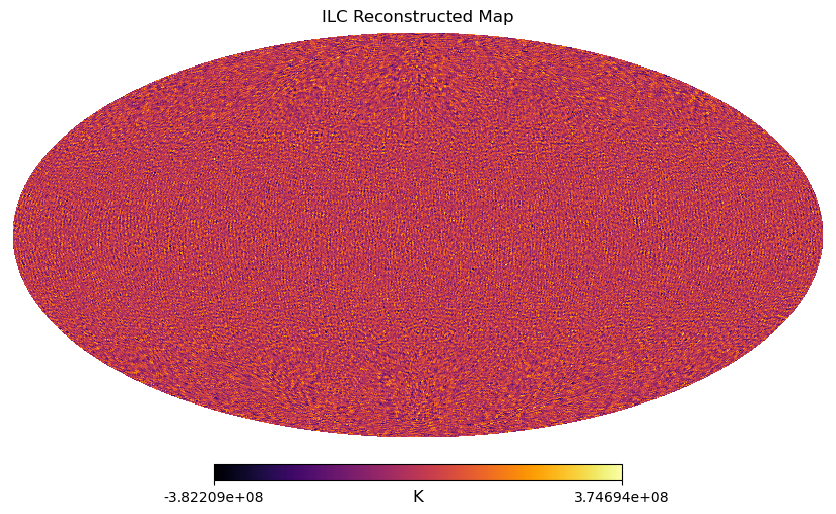

In [10]:
### PLOT THE RESULTING ILC MAP ###
hp.mollview(ilc_result, title="ILC Reconstructed Map", unit="K", cmap='inferno')
plt.show()


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?


is this really what you want?



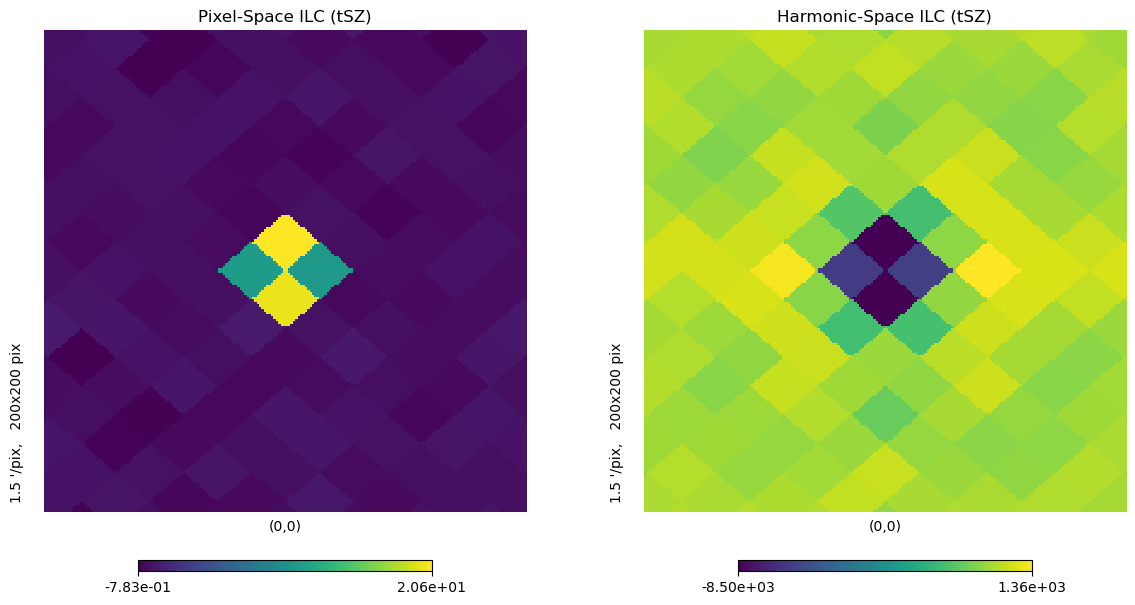

In [ ]:
### COMPARISON OF PIXEL-SPACE AND HARMONIC-SPACE ILC ###

# 1. Define frequencies and tSZ spectrum (the 'g' vector)
freqs = [100, 143, 217, 353, 545]
def get_tsz_g(nu_ghz):
    T_cmb = 2.7255
    x = (6.626e-34 * nu_ghz * 1e9) / (1.38e-23 * T_cmb)
    return x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4

g_vector = np.array([get_tsz_g(f) for f in freqs])

# 2. Load the maps you saved in the simulation notebook
maps = [hp.read_map(f'simulated_map_{f}GHz.fits') for f in freqs]
maps = np.array(maps)

# --- METHOD A: Pixel-Space ILC (Supervisor's version) ---
n_freq, n_pix = maps.shape
C_pixel = (1.0 / n_pix) * (maps @ maps.T)
C_inv_pixel = np.linalg.pinv(C_pixel)
w_pixel = (C_inv_pixel @ g_vector) / (g_vector.T @ C_inv_pixel @ g_vector)
y_pixel = w_pixel @ maps

# --- METHOD B: Harmonic-Space ILC ---
lmax = 1000
l_bins = [2, 100, 300, 700, 1000]
alms_list = [hp.map2alm(m, lmax=lmax) for m in maps]
final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
ell, _ = hp.Alm.getlm(lmax)

for i in range(len(l_bins)-1):
    mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
    bin_alms = np.array([alms[mask] for alms in alms_list])
    cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
    inv_cov = np.linalg.pinv(cov_bin)
    w_bin = (inv_cov @ g_vector) / (g_vector.T @ inv_cov @ g_vector)
    final_alms[mask] = w_bin @ bin_alms

y_harmonic = hp.alm2map(final_alms, nside=hp.npix2nside(n_pix))

# 3. Plotting the comparison
fig = plt.figure(figsize=(12, 6))
hp.gnomview(y_pixel, title="Pixel-Space ILC (tSZ)", sub=121, format="%.2e")
hp.gnomview(y_harmonic, title="Harmonic-Space ILC (tSZ)", sub=122, format="%.2e")
plt.show()